In [1]:
# enable all interactive output to be 'printed'
# and disable scrolling so long output can be displayed w/o scroll bars

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [3]:
# methods for displaying and maintaining an image in jupyter frontend
from IPython.display import Image, display

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Repeat code for Preprocessing Image Data for Elephant Classification

In [6]:
import os
import numpy as np
from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
# Retrieve image data
extract_path = os.getcwd() + '\elephant_dataset'

train_dir = Path(extract_path) / "train"
test_dir = Path(extract_path) / "test"

# Print the contents
print("Training data folders:", os.listdir(train_dir))
print("Testing data folders:", os.listdir(test_dir))

# These directories should have two subfolders: 'asian' and 'african'

Training data folders: ['African', 'Asian']
Testing data folders: ['African', 'Asian']


In [8]:
# Step 3: Resize and Normalize Images

image_size = (128, 128)  # previous resizing was 150x150 pixels
batch_size = 32

In [9]:
# Step 4: Set Up Image Data Generators

# Keras' ImageDataGenerator is used for:
# 1. Rescaling pixel values
# 2. Real-time data augmentation (which helps prevent overfitting)
# 3. Loading images in batches for training and validation

# Create an ImageDataGenerator instance for the training data, including augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,         # Normalize the images by dividing pixel values by 255 (to scale between 0 and 1)
    rotation_range=40,     # Randomly rotate images by 0 to 40 degrees
    width_shift_range=0.2, # Shift images horizontally by 20% of the total width
    height_shift_range=0.2,# Shift images vertically by 20% of the total height
    shear_range=0.2,       # Apply shearing transformation to images
    zoom_range=0.2,        # Randomly zoom the images
    horizontal_flip=True,  # Flip images horizontally for data augmentation
    fill_mode='nearest'    # Fill missing pixels after transformation with nearest pixel values
)

# Create a validation data generator (we don't want augmentation here, only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerator created")

ImageDataGenerator created


In [11]:
# Step 5: Load Images from Directories

# Using flow_from_directory to load and preprocess images from the directory
# This function will automatically categorize images based on the folder names ('asian', 'african').

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,     # Path to the train directory
    target_size=image_size,  # Resize images to 150x150 pixels
    batch_size=batch_size,   # Set the batch size for the data
    class_mode='binary'      # Since this is a binary classification task (Asian vs African elephants)
)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir,       # Path to the validation directory
    target_size=image_size,  # Resize images to 150x150 pixels
    batch_size=batch_size,   # Set the batch size for validation data
    class_mode='binary'      # Binary classification (either 'asian' or 'african')
)

(print(type(test_generator)))

Found 1010 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
<class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>


In [14]:
# Import necessary libraries for CNN modeling

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [15]:
# Define the CNN architecture
model = Sequential()

# Add the first convolutional layer (Conv2D), followed by MaxPooling2D
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))  # 128x128 image with 3 color channels (RGB)
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output of the last convolutional layer to feed into the Dense layers
model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # Output layer with 2 nodes (for two classes: 'asian' and 'african')

In [16]:
# Summarize the model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 127008)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       8,128,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,129,602 (31.01 MB)

 Trainable params: 8,129,602 (31.01 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer='adam',                # How the model updates weights
    loss='sparse_categorical_crossentropy', # How it calculates error (adjust based on your labels)
    metrics=['accuracy']             # What to report during training
)

In [33]:
# Train the model
# Assuming train_data and test_data are prepared earlier (using the previous preprocessing steps)
# Here, we use 10 epochs and batch size of 32 for this example, adjust as needed

history = model.fit(
    train_generator,
    epochs=10, 
    validation_data=test_generator
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 154s 4s/step - accuracy: 0.5690 - loss: 1.7772 - val_accuracy: 0.5000 - val_loss: 1.0079
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.5746 - loss: 0.7194 - val_accuracy: 0.6100 - val_loss: 0.6125
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step - accuracy: 0.6198 - loss: 0.6509 - val_accuracy: 0.7300 - val_loss: 0.5231
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.6464 - loss: 0.6216 - val_accuracy: 0.7300 - val_loss: 0.4961
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.6039 - loss: 0.6286 - val_accuracy: 0.7400 - val_loss: 0.5005
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 148s 4s/step - accuracy: 0.6581 - loss: 0.6197 - val_accuracy: 0.7100 - val_loss: 0.5411
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.6500 - loss: 0.6137 - val_accuracy: 0.7600 - val_loss: 0.4926
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.6514 - loss: 0.6157 - val_accuracy: 0.7200 - v

In [37]:
# Evaluate the model on test data to see how well it performs on unseen data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.7441 - loss: 0.4982
Test Loss: 0.5162535905838013, Test Accuracy: 0.7300000190734863


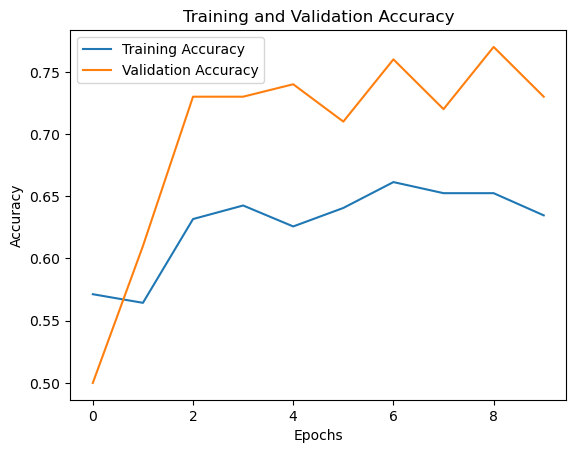

In [39]:
# Plot the training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show();

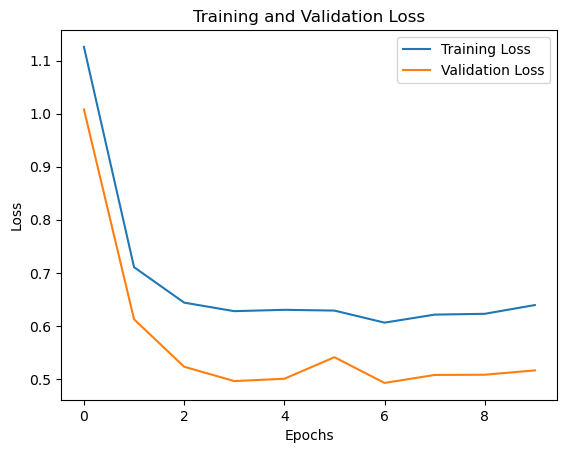

In [40]:
# Plot the training and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

Note:
This is a basic CNN model designed for simplicity and quick experimentation, rather than achieving high accuracy. While this architecture provides a solid starting point for image classification tasks, its performance might not be optimal compared to more advanced models.